In [2]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"]="2"  # specify which GPU(s) to be used
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os.path
import math

import pandas as pd
import numpy as np
from numpy import inf
from matplotlib import pyplot as plt
import seaborn as sns
import plotly
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense , Dropout, Conv2D ,Flatten
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [3]:
CTW_labelled = "/Users/chuansun/Downloads/CTW2020_labelled_data/"

In [5]:
def get_data(data_file):
    
    f = h5py.File(data_file, 'r')
    H_Re = f['H_Re'][:] #shape (sample size, 56, 924, 5)
    H_Im = f['H_Im'][:] #shape (sample size, 56, 924, 5)
    SNR = f['SNR'][:] #shape (sample size, 56, 5)
    Pos = f['Pos'][:] #shape(sample size, 3)
    f.close()
            
    return H_Re, H_Im, SNR, Pos        

# load data from file_1.hdf4

data_file = CTW_labelled+"file_"+str(1)+".hdf5"
H_Re, H_Im, SNR, Pos = get_data(data_file)
print("H_Re is of shape {}".format(H_Re.shape))
print("H_Im is of shape {}".format(H_Im.shape))
print("SNR is of shape {}".format(SNR.shape))
print("Pos is of shape {}".format(Pos.shape))

H_Re is of shape (512, 56, 924, 5)
H_Im is of shape (512, 56, 924, 5)
SNR is of shape (512, 56, 5)
Pos is of shape (512, 3)


In [6]:
# Euclidean norm
H = np.sqrt(H_Re[:,:]**2 + H_Im[:,:]**2)

# Extracting phase
arctan = np.divide(H_Re[:,:], H_Im[:,:])
arctan[np.isnan(arctan)] = math.pi / 2
arctan.shape

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning:

divide by zero encountered in true_divide

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning:

overflow encountered in true_divide

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning:

invalid value encountered in true_divide



(512, 56, 924, 5)

In [7]:
h = H[0][0][0]
phase = arctan[0][0][0]
np.vstack((h, phase)).reshape(-1)

array([0.1469, 0.1517, 0.1512, 0.1583, 0.1528, 2.125 , 1.214 , 1.7   ,
       1.828 , 1.724 ], dtype=float16)

In [8]:
# append phase onto H
h1 = np.empty([512, 56, 924, 10])
for d1 in range(512):
    for d2 in range(56):
        for d3 in range(924):
            h = H[d1][d2][d3]
            phase = arctan[d1][d2][d3]
            h1[d1][d2][d3] = np.vstack((h, phase)).reshape(-1)
        
h1.shape

(512, 56, 924, 10)

In [9]:
# append SNR onto h1
snr_rep = np.repeat(SNR, 2, axis=1).reshape(512, 56, -1)
h2 = np.empty([512, 56, 925, 10])
for d1 in range(512):
    for d2 in range(56):
        h = h1[d1][d2]
        snr = snr_rep[d1][d2]
        h2[d1][d2] = np.vstack((h, snr))
        
h2.shape

(512, 56, 925, 10)

In [12]:
# replace inifinity values
h2[h2 == inf] = 0
h2[h2 == -inf] = 0

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/numpy/core/_methods.py:75: RuntimeWarning:

invalid value encountered in reduce



{'whiskers': [<matplotlib.lines.Line2D at 0x7f87ec38d128>,
 'caps': [<matplotlib.lines.Line2D at 0x7f87ec38d828>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f87ec37add8>],
 'medians': [<matplotlib.lines.Line2D at 0x7f87ec38df28>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f87ec3962e8>],
 'means': []}

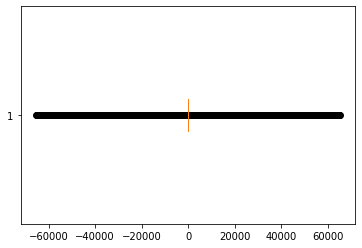

In [19]:
flatten = h2.reshape(-1)
plt.boxplot(flatten, vert=False)

In [ ]:
# h2 = np.empty([512, 56, 66])
# for i in range(56):
#     H2[:,i,:] = pca.transform(H[:,i,:])

In [13]:
# Train test split
x_train0, x_test0, y_train0, y_test0 = train_test_split(h2, Pos, test_size=0.1, random_state=42)
x_train0.shape, y_train0.shape

((460, 56, 925, 10), (460, 3))

In [7]:
def keras_model1(opt=Adam(1e-3)):
    model = Sequential()
    model.add(Conv2D(3,(5,5), input_shape=(x_train0.shape[1:]), activation='relu'))
    model.add(Conv2D(6,(5,5), activation='relu'))
    model.add(Conv2D(8,(5,5), activation='relu'))
    model.add(Flatten())
#     model.add(Dense(8192, activation='relu'))
#     model.add(Dense(4096, activation='relu'))
#     model.add(Dense(3072, activation='relu'))
#     model.add(Dense(2048, activation='relu'))
    model.add(Dense(1024, activation='relu'))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(3))
    model.compile(loss='mean_absolute_percentage_error', optimizer=opt) 
    return model

In [161]:
model0 = keras_model1(opt=Adam(1e-3))
earlystopper = EarlyStopping(patience=50, verbose=1)
#cp = ModelCheckpoint('v1_no_pca.h5', verbose=1, save_best_only=True)
hist0 = model0.fit(x_train0, y_train0, epochs=1, validation_data=(x_test0, y_test0),
                 callbacks=[earlystopper], batch_size=4, verbose=1)
#val_loss = hist.history['val_loss']

115/115 [==============================] - 778s 7s/step - loss: 125.9891 - val_loss: 141.9411


In [28]:
def keras_model2(opt=Adam(1e-3)):
    model = Sequential()
    model.add(Conv2D(32,(3,3),activation='linear', padding='same',input_shape=x_train.shape[1:]))
    model.add(Conv2D(16,(3,3),activation='linear', padding='same'))
    model.add(Flatten())
    model.add(Dense(512 ,activation = 'relu'))
    model.add(Dense(256 ,activation = 'relu' ))
    model.add(Dense(128 ,activation = 'relu' ))
    model.add(Dense(3))
    model.compile(loss="mean_absolute_percentage_error", optimizer=opt) 
    return model

Modeling after PCA

Try to explore the optimal number for PCA/other DR techniques as well

([<matplotlib.axis.XTick at 0x7fd88fdc2f28>,
 <a list of 100 Text major ticklabel objects>)

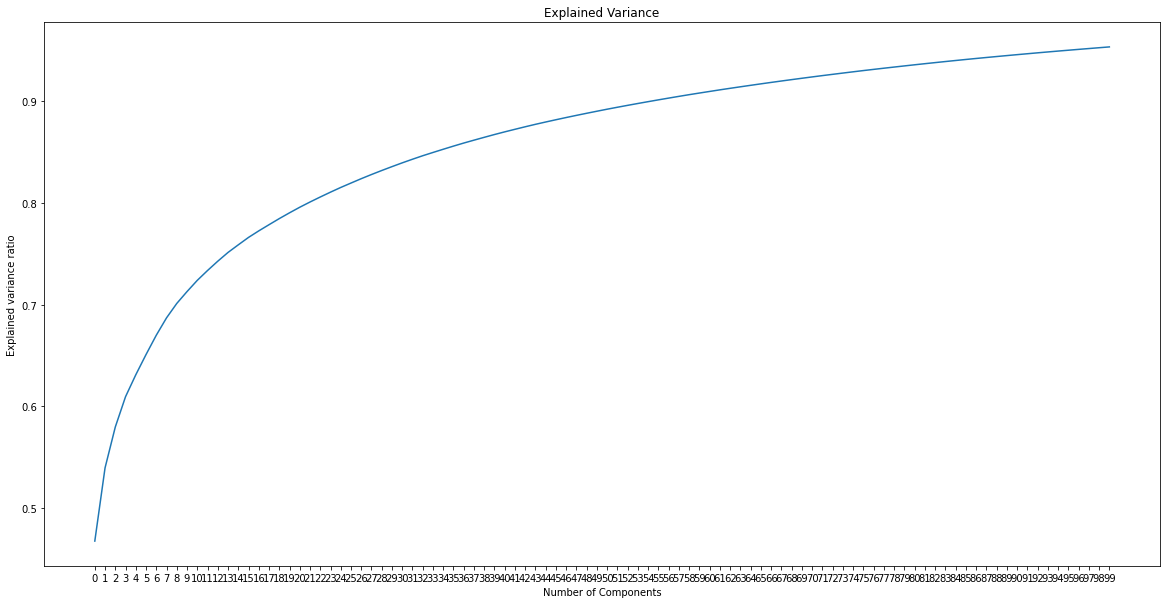

In [133]:
condense_to = 100
pca = PCA(n_components=condense_to)
pca.fit_transform(h2.reshape(512, -1))
plt.figure(figsize=(20, 10))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Explained variance ratio")
plt.title("Explained Variance")
plt.xticks(np.arange(0, condense_to, 1))

In [140]:
cumsum = np.cumsum(pca.explained_variance_ratio_)
cumsum[55]

0.9012218983573648

In [14]:
condense_to = 55
h2_pca = np.empty((h2.shape[0], h2.shape[1], condense_to, h2.shape[3]))


evrs = []
for i in range(h2.shape[1]):
    for j in range(h2.shape[3]):
        pca = PCA(n_components=condense_to)
        h2_pca[:, i, :, j] = pca.fit_transform(h2[:, i, :, j])
        evr = np.cumsum(pca.explained_variance_ratio_)
        evrs.append(evr)
        

#pca = PCA(n_components=condense_to)
#h2_pca = pca.fit_transform(h2.reshape(512, -1))
#h2_pca.shape

In [38]:
df_evrs = pd.DataFrame(evrs, columns=[f"p{x}" for x in range(len(evrs[0]))])
df_evrs

,p0,p1,p2,p3,p4,p5,p6,p7,p8,p9,...,p45,p46,p47,p48,p49,p50,p51,p52,p53,p54
0,0.983533,0.998830,0.999252,0.999460,0.999601,0.999674,0.999742,0.999793,0.999824,0.999848,...,0.999974,0.999975,0.999976,0.999977,0.999977,0.999978,0.999979,0.999980,0.999980,0.999981
1,0.983997,0.998828,0.999256,0.999465,0.999606,0.999679,0.999747,0.999798,0.999829,0.999852,...,0.999975,0.999976,0.999977,0.999977,0.999978,0.999979,0.999980,0.999980,0.999981,0.999982
2,0.983728,0.998839,0.999261,0.999465,0.999603,0.999675,0.999744,0.999795,0.999826,0.999850,...,0.999973,0.999974,0.999975,0.999976,0.999977,0.999978,0.999978,0.999979,0.999980,0.999980
3,0.983974,0.998839,0.999261,0.999466,0.999606,0.999678,0.999747,0.999794,0.999825,0.999848,...,0.999974,0.999975,0.999976,0.999977,0.999977,0.999978,0.999979,0.999980,0.999980,0.999981
4,0.983724,0.998852,0.999265,0.999469,0.999606,0.999679,0.999750,0.999796,0.999827,0.999851,...,0.999974,0.999975,0.999976,0.999977,0.999978,0.999978,0.999979,0.999980,0.999981,0.999981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,0.248210,0.404323,0.485931,0.551658,0.614535,0.665601,0.695783,0.723290,0.741151,0.754194,...,0.947896,0.949445,0.950946,0.952429,0.953891,0.955318,0.956739,0.958098,0.959398,0.960605
556,0.231363,0.447514,0.557668,0.607920,0.654185,0.689874,0.719848,0.748609,0.769971,0.789426,...,0.967537,0.968934,0.970132,0.971310,0.972419,0.973494,0.974531,0.975556,0.976541,0.977362
557,0.235376,0.367190,0.481900,0.564125,0.632580,0.676285,0.710588,0.735889,0.760855,0.779918,...,0.958900,0.960082,0.961192,0.962287,0.963302,0.964316,0.965323,0.966324,0.967226,0.968114
558,0.178647,0.317735,0.386904,0.447945,0.502816,0.556616,0.603142,0.645688,0.683308,0.719970,...,0.973389,0.974514,0.975603,0.976553,0.977459,0.978355,0.979146,0.979929,0.980647,0.981347


([<matplotlib.axis.XTick at 0x7f86325c6048>,
 <a list of 55 Text major ticklabel objects>)

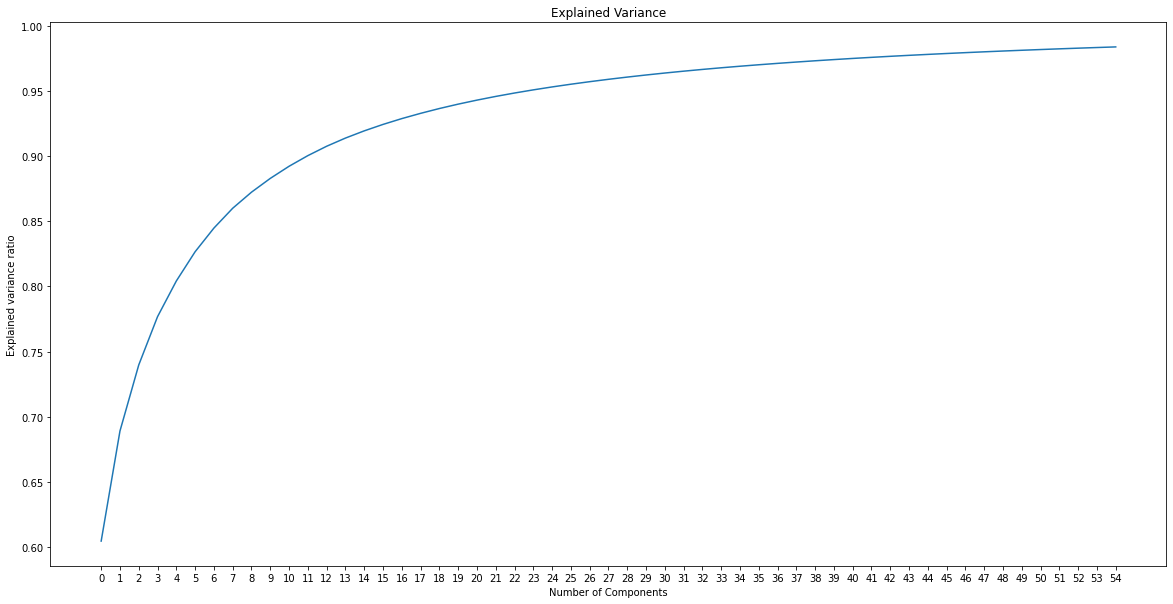

In [42]:
avg_evrs = []
for col in df_evrs.columns:
    avg_evrs.append(df_evrs[col].mean())

plt.figure(figsize=(20, 10))
plt.plot(avg_evrs)
plt.xlabel("Number of Components")
plt.ylabel("Explained variance ratio")
plt.title("Explained Variance")
plt.xticks(np.arange(0, len(avg_evrs), 1))

In [15]:
# Train test split after PCA
x_train, x_test , y_train , y_test = train_test_split(h2_pca, Pos, test_size=0.1, random_state=42)
x_train.shape, y_train.shape

((460, 56, 55, 10), (460, 3))

dropouts & BN, dense layers only(without PCA)
normalization
MSE error
learning rate schedule
try batch sizes

In [ ]:
def keras_model3(opt=Adam(1e-3), dropout_rate=0.2):
    model = Sequential()
    model.add(Dense(512, input_shape=x_train0.shape[1:], activation='relu'))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(rate=dropout_rate))
#     model.add(Dense(128, activation='relu'))
#     model.add(Dropout(rate=dropout_rate))
#     model.add(Dense(32, activation='relu'))
#     model.add(Dropout(rate=dropout_rate))
#     model.add(Dense(16, activation='relu'))
    model.add(Dense(3))
    model.compile(loss='mean_squared_error', optimizer=opt)
    return model
    
model = keras_model3(opt=Adam(5e-3), dropout_rate=0.2)
earlystopper = EarlyStopping(patience=50, verbose=1)
#cp = ModelCheckpoint('v1_no_pca.h5', verbose=1, save_best_only=True)
hist1 = model.fit(x_train, y_train , epochs=10, validation_data=(x_test, y_test),
                  callbacks=[earlystopper], batch_size=4, verbose=1)
pd.DataFrame(hist1.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Epoch 1/10
115/115 [==============================] - 15s 130ms/step - loss: 1459208.6250 - val_loss: 36829.7031
Epoch 2/10
115/115 [==============================] - 14s 125ms/step - loss: 37346.4219 - val_loss: 35069.0859
Epoch 3/10
115/115 [==============================] - 15s 128ms/step - loss: 30220.0234 - val_loss: 34081.8242
Epoch 4/10
115/115 [==============================] - 14s 125ms/step - loss: 28732.0527 - val_loss: 34480.8516
Epoch 5/10
115/115 [==============================] - 14s 124ms/step - loss: 27935.3184 - val_loss: 37431.2344
Epoch 6/10
115/115 [==============================] - 15s 130ms/step - loss: 24980.3086 - val_loss: 34027.1445
Epoch 7/10
115/115 [==============================] - 15s 135ms/step - loss: 21524.0332 - val_loss: 37127.9531
Epoch 8/10
115/115 [==============================] - 15s 126ms/step - loss: 22883.3301 - val_loss: 38044.8008
Epoch 9/10
115/115 [==============================] - 15s 127ms/step - loss: 21328.0176 - val_loss: 38710.3711

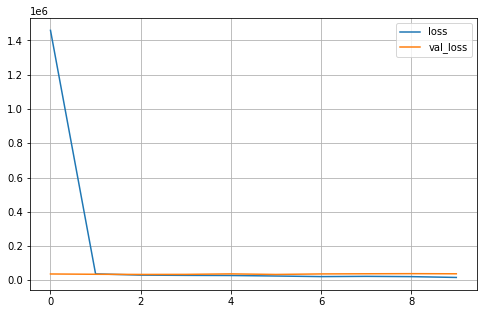

In [48]:
def keras_model1(opt=Adam(1e-3)):
    model = Sequential()
    model.add(Conv2D(32,(3,3), input_shape=(x_train.shape[1:]), activation='relu'))
    model.add(Conv2D(16,(3,3), activation='relu'))
    model.add(Conv2D(8,(3,3), activation='relu'))
    #model.add(Conv2D(8,(3,3), activation='relu'))
    model.add(Flatten())
#     model.add(Dense(8192, activation='relu'))
#     model.add(Dense(4096, activation='relu'))
#     model.add(Dense(3072, activation='relu'))
#     model.add(Dense(2048, activation='relu'))
    model.add(Dense(1024, activation='relu'))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(3))
    model.compile(loss='mean_squared_error', optimizer=opt) 
    return model


model = keras_model1(opt=Adam(5e-3))
earlystopper = EarlyStopping(patience=50, verbose=1)
#cp = ModelCheckpoint('v1_no_pca.h5', verbose=1, save_best_only=True)
hist1 = model.fit(x_train, y_train , epochs=10, validation_data=(x_test, y_test),
                 callbacks=[earlystopper], batch_size=4, verbose=1)
pd.DataFrame(hist1.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Epoch 1/50
115/115 [==============================] - 10s 83ms/step - loss: 91.9537 - val_loss: 103.8214
Epoch 2/50
115/115 [==============================] - 9s 82ms/step - loss: 89.3929 - val_loss: 89.6268
Epoch 3/50
115/115 [==============================] - 9s 78ms/step - loss: 74.6693 - val_loss: 82.6517
Epoch 4/50
115/115 [==============================] - 9s 78ms/step - loss: 125.8321 - val_loss: 97.2173
Epoch 5/50
115/115 [==============================] - 9s 78ms/step - loss: 81.9386 - val_loss: 98.1366
Epoch 6/50
115/115 [==============================] - 9s 77ms/step - loss: 83.8057 - val_loss: 174.2242
Epoch 7/50
115/115 [==============================] - 9s 77ms/step - loss: 112.6022 - val_loss: 99.4569
Epoch 8/50
115/115 [==============================] - 9s 78ms/step - loss: 99.3887 - val_loss: 98.6217
Epoch 9/50
115/115 [==============================] - 9s 77ms/step - loss: 98.6906 - val_loss: 97.6874
Epoch 10/50
115/115 [==============================] - 9s 80ms/step 

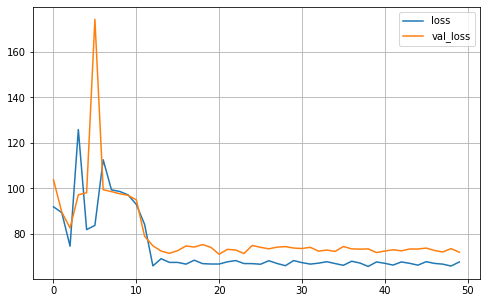

In [59]:
def keras_model2(opt=Adam(1e-3)):
    model = Sequential()
    model.add(Conv2D(32,(3,3),activation='elu', padding='same', input_shape=x_train.shape[1:]))
    model.add(Conv2D(16,(3,3),activation='elu', padding='same'))
    model.add(Conv2D(8,(3,3),activation='elu', padding='same'))
    model.add(Flatten())
    model.add(Dense(512 ,activation='relu'))
    model.add(Dense(256 ,activation='relu'))
    model.add(Dense(128 ,activation='relu'))
    model.add(Dense(64 ,activation='relu'))
    model.add(Dense(3))
    model.compile(loss="mean_absolute_percentage_error", optimizer=opt) 
    return model

model = keras_model2(opt=Adam(5e-3))
earlystopper = EarlyStopping(patience=50, verbose=1)
#cp = ModelCheckpoint('v1_no_pca.h5', verbose=1, save_best_only=True)
hist2 = model.fit(x_train, y_train , epochs=50, validation_data=(x_test, y_test),
                 callbacks=[earlystopper], batch_size=4, verbose=1)
pd.DataFrame(hist2.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()